### Analyse overall statistics of nutrient export data of all 3496 catchments 
This script is used to calculate statistics like the overall mean median absolute nutrient concentrations as well as mean andd median of Redfield ratio normalized concentrations

INPUT DATA:

* input data used for machine learning methods: ../../../output_data/input_ML_learning/median_cnp_export_abs_conc_and_rfr_and_basin_feat.csv'


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Import dataset:

In [2]:
nutrient_export_data = pd.read_csv('../../output_data/input_ML_learning/median_cnp_export_abs_conc_and_rfr_and_basin_feat.csv').drop(columns='Unnamed: 0')

In [3]:
nutrient_export_data

,HYBAS_ID,c_imbal,n_imbal,p_imbal,median_DOC_TOC_bioav,median_DIN,median_SRP,UP_AREA,twi90,slp_dg_uav,...,pac_pc_use,cly_pc_uav,slt_pc_uav,snd_pc_uav,soc_th_uav,swc_pc_uyr,kar_pc_use,ero_kh_uav,gdp_ud_usu,hdi_ix_sav
0,1121145450,0.029363,0.501158,0.469480,0.084407,0.253667,0.032831,20609.9,8.826505,48,...,20,32,23,44,27,49,0,11117,1.175299e+10,555
1,1121146530,0.007609,0.583281,0.409110,0.100636,1.358399,0.131635,18829.3,8.074445,50,...,18,32,23,44,28,51,0,11470,1.130367e+10,555
2,1121150540,0.031992,0.735331,0.232677,0.054268,0.219630,0.009602,109.9,8.204151,67,...,22,36,26,39,35,68,0,12078,6.879562e+07,555
3,1121151290,0.013639,0.113814,0.872547,0.072643,0.106733,0.113051,265.1,9.421020,89,...,59,33,26,41,56,75,0,11736,8.293591e+07,555
4,1121151840,0.025477,0.314462,0.660061,0.114009,0.247784,0.071857,32034.9,9.312500,35,...,27,32,24,44,22,38,0,7784,1.263985e+10,555
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3491,8120253120,0.096346,0.379972,0.523682,0.302400,0.209996,0.039986,80185.4,6.915997,91,...,10,13,42,43,106,85,2,1660,4.468250e+07,948
3492,8120256970,0.045640,0.882384,0.071976,0.052477,0.178642,0.002013,111.5,5.486714,222,...,62,7,34,58,148,89,0,3379,2.679400e+05,948
3493,8120280400,0.068245,0.797126,0.134629,0.072929,0.149992,0.003500,5195.2,15.634457,128,...,88,10,37,52,122,91,0,2878,9.341507e+08,948
3494,8120295370,0.380209,0.272594,0.347197,0.720821,0.090998,0.016013,180.3,8.519233,33,...,0,10,45,45,133,89,0,64,6.378524e+07,948


Select only nutrient data:

In [4]:
targets = nutrient_export_data[['median_DOC_TOC_bioav', 'median_DIN', 'median_SRP', 'c_imbal', 'n_imbal', 'p_imbal']]

Calculate overall nutrient data stats and organise in a data frame:

In [5]:
stats_nutrients_all_catchments = targets.describe(percentiles = [0.025, 0.5, 0.975]).T

In [6]:
stats_nutrients_all_catchments = stats_nutrients_all_catchments.drop(columns = {'count'})

In [7]:
stats_nutrients_all_catchments['variable'] = ['median rOC', 'median DIN', 'median SRP', 'rOC_RFR', 'DIN_RFR', 'SRP_RFR']

In [8]:
stats_nutrients_all_catchments = stats_nutrients_all_catchments.rename(columns = {'50%':'median'})

In [9]:
stats_nutrients_all_catchments = stats_nutrients_all_catchments[['variable', 'mean', 'std', 'min', '2.5%', 'median', '97.5%', 'max']].reset_index(drop = True)

In [10]:
stats_nutrients_all_catchments

,variable,mean,std,min,2.5%,median,97.5%,max
0,median rOC,0.464494,0.622411,0.000406,0.063825,0.332640,1.512095,19.141920
1,median DIN,2.170101,2.359451,0.008000,0.076002,1.198036,7.998868,24.300523
2,median SRP,0.082856,0.281027,0.000496,0.003252,0.031836,0.420033,11.351109
3,rOC_RFR,0.070526,0.099262,0.000467,0.005156,0.031700,0.365265,0.902458
4,DIN_RFR,0.729414,0.212464,0.020659,0.177533,0.799905,0.963512,0.993063
5,SRP_RFR,0.200059,0.172779,0.003755,0.020642,0.144701,0.686839,0.963469


Save dataframe as excel file:

In [12]:
stats_nutrients_all_catchments.to_excel('../../output_data/CNP_data_catchments/statistics_nutrient_data_all_catchments.xlsx')

Create histograms of absolute nutrient concentrations:

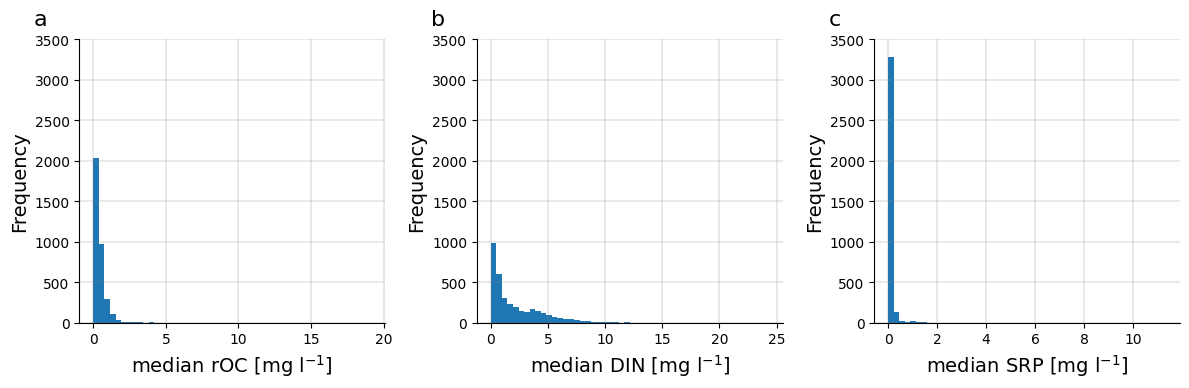

In [13]:
fig, axes = plt.subplots(1,3, figsize = (12, 4)) 

axes = axes.flatten()

axes[0].hist(targets['median_DOC_TOC_bioav'], bins = 50)
axes[0].set_ylim(0, 3500)
axes[0].text(-0.15, 1.05, 'a', transform=axes[0].transAxes, 
             size=16)#, weight='bold')
axes[0].grid(color='gray', linestyle='-', linewidth=0.25, zorder = -1)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].set_xlabel('median rOC [mg l$^{-1}$]', fontsize = 14)
axes[0].set_ylabel('Frequency', fontsize = 14)


axes[1].hist(targets['median_DIN'], bins = 50)
axes[1].set_ylim(0, 3500)
axes[1].text(-0.15, 1.05, 'b', transform=axes[1].transAxes, 
             size=16)#, weight='bold')
axes[1].grid(color='gray', linestyle='-', linewidth=0.25, zorder = -1)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].set_xlabel('median DIN [mg l$^{-1}$]', fontsize = 14)
axes[1].set_ylabel('Frequency', fontsize = 14)


axes[2].hist(targets['median_SRP'], bins = 50)
axes[2].set_ylim(0, 3500)
axes[2].text(-0.15, 1.05, 'c', transform=axes[2].transAxes, 
             size=16)#, weight='bold')
axes[2].grid(color='gray', linestyle='-', linewidth=0.25, zorder = -1)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)
axes[2].set_xlabel('median SRP [mg l$^{-1}$]', fontsize = 14)
axes[2].set_ylabel('Frequency', fontsize = 14)


plt.tight_layout()
plt.show()